In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/house_prices.csv")

print("=" * 50)
print("First 5 Rows")
print("=" * 50)
print(df.head())

print("=" * 50)
print("Shape")
print("=" * 50)
print(df.shape)

print("=" * 50)
print("Columns")
print("=" * 50)
print(df.columns)

print("=" * 50)
print("Information")
print("=" * 50)
print(df.info())

print("=" * 50)
print("Missing Values")
print("=" * 50)
print(df.isnull().sum())

print("=" * 50)
print("Statistical Summary")
print("=" * 50)
print(df.describe())

First 5 Rows
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  
0     1.5           0     0          3  
1     2.0           0     4          5  
2     1.0           0     0          4  
3     1.0           0     0          4  
4     1.0           0     0          4  
Shape
(4600, 10)
Columns
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition'],
      dtype='str')
Information
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data c

In [14]:
print("Duplicate Rows :", df.duplicated().sum())


Duplicate Rows : 0


In [15]:
df.sample(5)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition
4055,2014-07-08 00:00:00,378500.000000,3.0,2.50,2860,43821,2.0,0,0,4
287,2014-05-07 00:00:00,239900.000000,3.0,2.00,1410,7566,1.0,0,0,3
4414,2014-05-22 00:00:00,240015.333333,4.0,2.25,1720,8300,1.0,0,0,4
4379,2014-05-12 00:00:00,268971.875000,4.0,2.50,2380,7066,2.0,0,0,4
2291,2014-06-11 00:00:00,650000.000000,2.0,1.00,1030,5750,1.0,0,0,5


In [16]:
df.dtypes


date               str
price          float64
bedrooms       float64
bathrooms      float64
sqft_living      int64
sqft_lot         int64
floors         float64
waterfront       int64
view             int64
condition        int64
dtype: object

In [17]:
print(df["price"].min())
print(df["price"].max())
print(df["price"].mean())

0.0
26590000.0
551962.9884732141


In [18]:
df["bedrooms"].value_counts()

bedrooms
3.0    2032
4.0    1531
2.0     566
5.0     353
6.0      61
1.0      38
7.0      14
8.0       2
0.0       2
9.0       1
Name: count, dtype: int64

In [19]:
df["floors"].value_counts()


floors
1.0    2174
2.0    1811
1.5     444
3.0     128
2.5      41
3.5       2
Name: count, dtype: int64

In [20]:
df["condition"].value_counts()

condition
3    2875
4    1252
5     435
2      32
1       6
Name: count, dtype: int64

1. Price Distribution (Histogram)

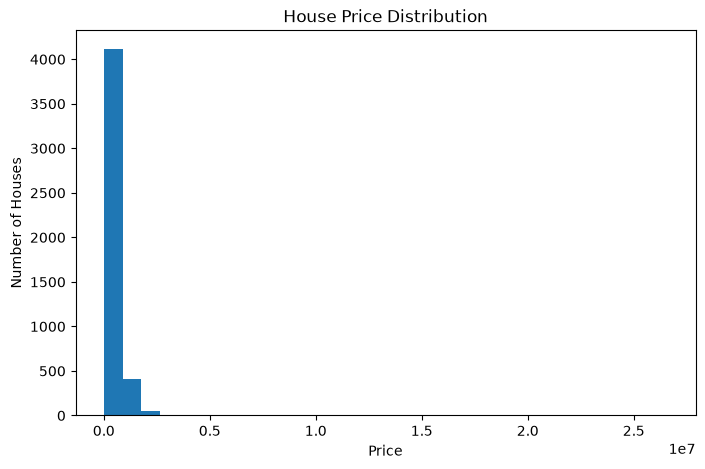

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=30)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

2. Living Area vs Price (Scatter Plot)

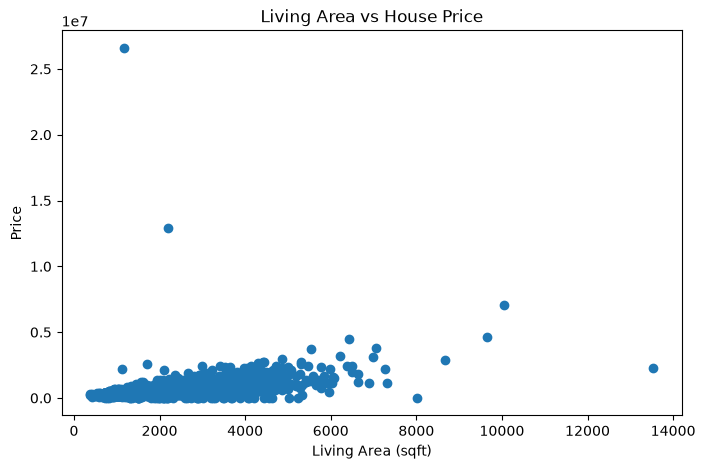

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(df["sqft_living"], df["price"])

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")

plt.show()

3. Bedrooms Count (Bar Chart)

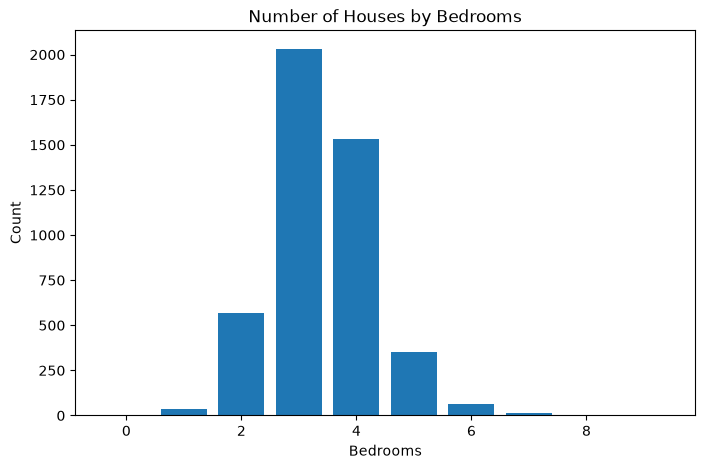

In [23]:
bedroom_count = df["bedrooms"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(bedroom_count.index, bedroom_count.values)

plt.title("Number of Houses by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Count")

plt.show()

4. Condition Count

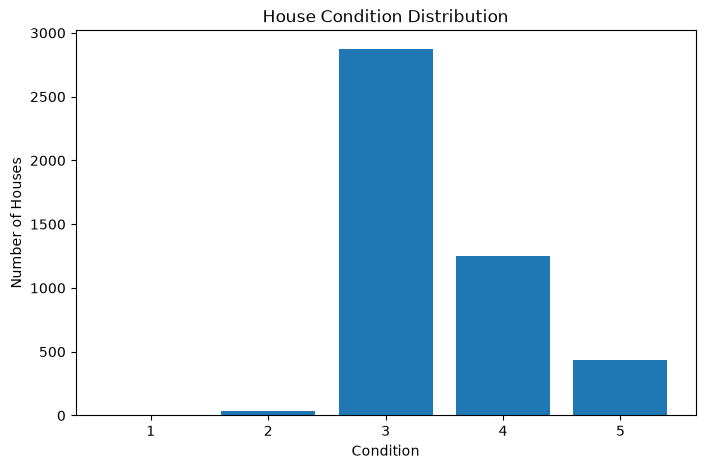

In [24]:
condition_count = df["condition"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(condition_count.index, condition_count.values)

plt.title("House Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Number of Houses")

plt.show()

5. Waterfront Houses

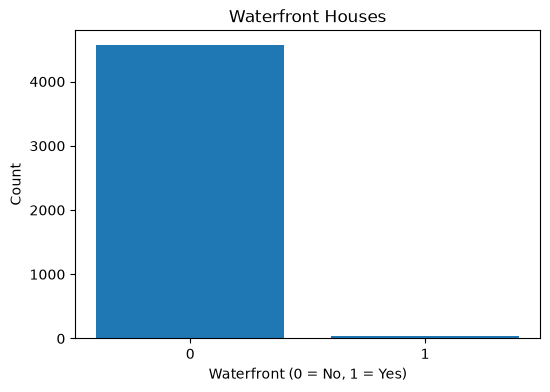

In [ ]:
waterfront_count = df["waterfront"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(waterfront_count.index.astype(str), waterfront_count.values)

plt.title("Waterfront Houses")
plt.xlabel("Waterfront (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()S

In [26]:
correlation = df.corr(numeric_only=True)

print(correlation)

                price  bedrooms  bathrooms  sqft_living  sqft_lot    floors  \
price        1.000000  0.200336   0.327110     0.430410  0.050451  0.151461   
bedrooms     0.200336  1.000000   0.545920     0.594884  0.068819  0.177895   
bathrooms    0.327110  0.545920   1.000000     0.761154  0.107837  0.486428   
sqft_living  0.430410  0.594884   0.761154     1.000000  0.210538  0.344850   
sqft_lot     0.050451  0.068819   0.107837     0.210538  1.000000  0.003750   
floors       0.151461  0.177895   0.486428     0.344850  0.003750  1.000000   
waterfront   0.135648 -0.003483   0.076232     0.117616  0.017241  0.022024   
view         0.228504  0.111028   0.211960     0.311009  0.073907  0.031211   
condition    0.034915  0.025080  -0.119994    -0.062826  0.000558 -0.275013   

             waterfront      view  condition  
price          0.135648  0.228504   0.034915  
bedrooms      -0.003483  0.111028   0.025080  
bathrooms      0.076232  0.211960  -0.119994  
sqft_living    0.1176

In [27]:
correlation["price"].sort_values(ascending=False)

price          1.000000
sqft_living    0.430410
bathrooms      0.327110
view           0.228504
bedrooms       0.200336
floors         0.151461
waterfront     0.135648
sqft_lot       0.050451
condition      0.034915
Name: price, dtype: float64

heatmap using Matplotlib:

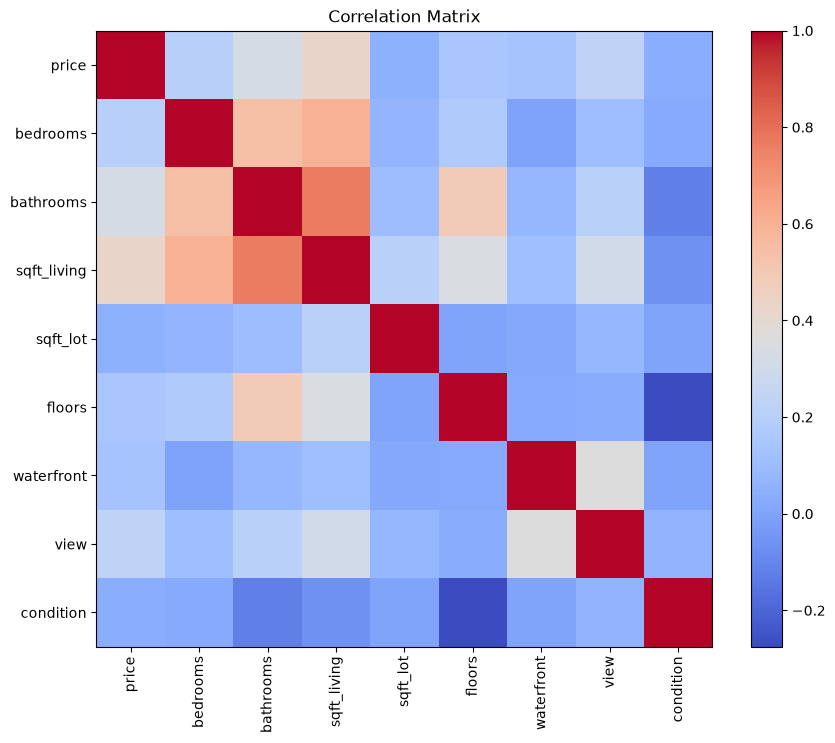

In [28]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()